In [126]:
#Import Dependencies 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [127]:
#Loading the downloaded dataset into the pandas dataframe 
interview_data = pd.read_csv(r'C:\Users\USER\Desktop\interview_package\interview_dataset.csv')

C:\Users\USER\AppData\Local\Temp\ipykernel_3140\2375126717.py:2: DtypeWarning: Columns (102,116,128,142,154,180,194,246,343,359,367,380,484,615,725,737,806,827,857,859,999,1076,1191,1234,1263,1538,1541,1592,1593,1632,1679,1681,1723,1735,1770,1785,1804,1855,1857,2182,2230,2252,2368,2577,2580,2631,2632,2671,2742,2758,2784,2805,2858,2885,2927,3364,3372,3510,3540,3543,3557,3571,3628,3741,3788,3835,3863,3882,3920,3930,4006,4044,4053,4100,4157,4383,4402,4430,4506,4553,4929,4943,5005,5009,5013,5017,5077,5166,5174,5177,5222,5491,5504,5537,5736,5745,5845,5849,5855,5866,5878,5879,5901,5923,5931,5945,5967,5995,5996,6011,6017,6018,6075,6115,6118,6430,6440,6451,6475,6483,6525,6532,6703,6763,6808) have mixed types. Specify dtype option on import or set low_memory=False.
  interview_data = pd.read_csv(r'C:\Users\USER\Desktop\interview_package\interview_dataset.csv')


In [128]:
#Display the first five rows of the Interview dataset
interview_data.head()

,SubmissionDate,starttime,endtime,version,duration,survey_start,intro_start,text_audit,date_collection,region,...,HH Production UGX,HH Income + Production UGX,Program Value UGX,Assets,HH Income UGX/Day,HH Production UGX/Day,HH Income + Production UGX/Day,Program Value UGX/Day,STATUS,HH Income + Production/Day (USD)
0,"Aug 6, 2024 3:52:21 PM","Aug 6, 2024 11:50:32 AM","Aug 6, 2024 12:44:45 PM",2408061513,3093,7.0,7.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-07 00:00:00,4,...,1825000.0,5253000.0,6148000.0,895000,9391.780822,5000.000000,14391.780822,16843.835616,RTV,3.889670
1,"Aug 1, 2024 5:44:43 PM","Aug 1, 2024 11:36:23 AM","Aug 1, 2024 12:13:08 PM",2407311236,2003,62.0,62.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-02 00:00:00,4,...,786000.0,1335000.0,1335000.0,0,1504.109589,2153.424658,3657.534247,3657.534247,RTV,0.988523
2,"Aug 3, 2024 12:34:58 AM","Aug 2, 2024 4:13:56 PM","Aug 2, 2024 5:02:05 PM",2408021241,2890,7.0,7.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-03 00:00:00,4,...,1955000.0,2385000.0,2535000.0,150000,1178.082192,5356.164384,6534.246575,6945.205479,RTV,1.766013
3,"Aug 6, 2024 9:17:47 PM","Aug 6, 2024 10:44:39 AM","Aug 6, 2024 12:10:57 PM",2408061513,5178,5.0,5.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-07 00:00:00,2,...,789000.0,3510500.0,6160500.0,2650000,7456.164384,2161.643836,9617.808219,16878.082192,RTV,2.599408
4,"Aug 1, 2024 1:39:03 PM","Aug 1, 2024 12:20:03 PM","Aug 1, 2024 1:27:07 PM",2407302157,4024,5.0,5.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-02,4,...,868350.0,2326350.0,3276350.0,950000,3994.520548,2379.041096,6373.561644,8976.301370,RTV,1.722584


In [129]:
#Display the last five rows of the Interview dataset
interview_data.tail()

,SubmissionDate,starttime,endtime,version,duration,survey_start,intro_start,text_audit,date_collection,region,...,HH Production UGX,HH Income + Production UGX,Program Value UGX,Assets,HH Income UGX/Day,HH Production UGX/Day,HH Income + Production UGX/Day,Program Value UGX/Day,STATUS,HH Income + Production/Day (USD)
495,"Aug 1, 2024 6:21:55 PM","Aug 1, 2024 11:04:32 AM","Aug 1, 2024 12:00:03 PM",2407311236,3331,2.0,2.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-02,4,...,1061500.0,2645500.0,2715500.0,70000,4339.726027,2908.219178,7247.945205,7439.726027,RTV,1.958904
496,"Aug 7, 2024 9:10:44 PM","Aug 7, 2024 1:02:35 PM","Aug 7, 2024 2:06:50 PM",2408061513,3736,16.0,16.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-08,4,...,1455500.0,3335000.0,3945000.0,610000,5149.315068,3987.671233,9136.986301,10808.219178,RTV,2.469456
497,"Jul 30, 2024 7:22:54 PM","Jul 30, 2024 12:45:00 PM","Jul 30, 2024 3:53:20 PM",2407302157,3303,3.0,3.0,https://rtvuganda.surveycto.com/view/submissio...,2024-07-31 00:00:00,4,...,1960750.0,6156000.0,6201000.0,45000,11493.835616,5371.917808,16865.753425,16989.041096,RTV,4.558312
498,"Jul 29, 2024 7:41:46 PM","Jul 29, 2024 2:09:08 PM","Jul 29, 2024 3:26:55 PM",2407300828,4590,2.0,2.0,https://rtvuganda.surveycto.com/view/submissio...,2024-07-30 00:00:00,4,...,503000.0,1182000.0,1682000.0,500000,1860.273973,1378.082192,3238.356164,4608.219178,PEER,0.875231
499,"Aug 5, 2024 9:07:41 PM","Aug 5, 2024 1:48:58 PM","Aug 5, 2024 2:45:51 PM",2408060510,3413,4.0,4.0,https://rtvuganda.surveycto.com/view/submissio...,2024-08-06 00:00:00,4,...,2015000.0,4070000.0,4480000.0,410000,5630.136986,5520.547945,11150.684932,12273.972603,RTV,3.013699


In [130]:
#Print the number of rows and columns 
interview_data.shape

(500, 6905)

In [131]:
# Selecting columns to be used in model training (Key variables)
selected_columns = [
    'HH Income + Production/Day (USD)',
    'most_recommend_rtv_program',
    'least_recommend_rtv_program',
    'most_recommend_rtv_program_reason',
    'least_recommend_rtv_program_reason'
]

selected_data = interview_data.loc[:, selected_columns].copy(deep=True)

In [132]:
#Identifying datatypes of missing selected data
selected_data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   HH Income + Production/Day (USD)    500 non-null    float64
 1   most_recommend_rtv_program          380 non-null    float64
 2   least_recommend_rtv_program         380 non-null    float64
 3   most_recommend_rtv_program_reason   380 non-null    object 
 4   least_recommend_rtv_program_reason  380 non-null    object 
dtypes: float64(3), object(2)
memory usage: 19.7+ KB


In [133]:
1.	
#checking missing values 
selected_data.isnull().sum()

HH Income + Production/Day (USD)        0
most_recommend_rtv_program            120
least_recommend_rtv_program           120
most_recommend_rtv_program_reason     120
least_recommend_rtv_program_reason    120
dtype: int64

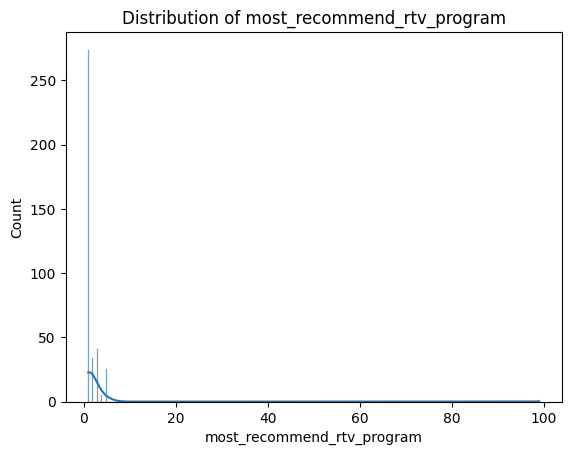

In [134]:
#Checking the distribution data in most_recommend_rtv_program to identify if to impute using mean or median
# Plotting distribution of 'most_recommend_rtv_program'
sns.histplot(selected_data['most_recommend_rtv_program'].dropna(), kde=True)
plt.title("Distribution of most_recommend_rtv_program")
plt.show()

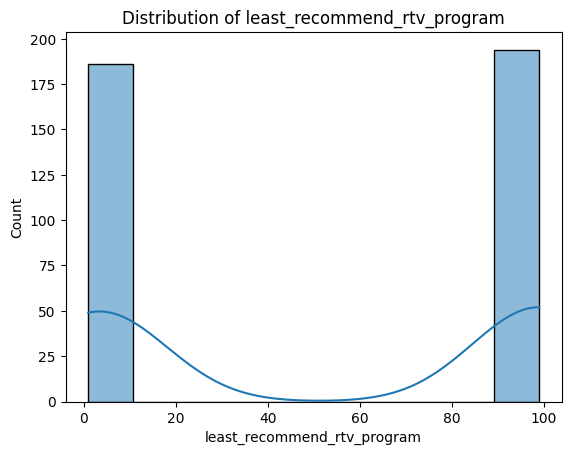

In [135]:
#Checking the distribution data in least_recommend_rtv_program to identify if to impute using mean or median
# Plotting distribution of 'least_recommend_rtv_program'
sns.histplot(selected_data['least_recommend_rtv_program'].dropna(), kde=True)
plt.title("Distribution of least_recommend_rtv_program")
plt.show()

In [136]:
#Understanding the statistical distribution of selected data for the model 
selected_data.describe()

,HH Income + Production/Day (USD),most_recommend_rtv_program,least_recommend_rtv_program
count,500.000000,380.000000,380.000000
mean,2.491505,1.865789,52.228947
std,1.525648,5.126926,47.837761
min,0.130914,1.000000,1.000000
25%,1.399759,1.000000,3.750000
50%,2.257867,1.000000,99.000000
75%,3.253091,2.000000,99.000000
max,11.836357,99.000000,99.000000


In [137]:
selected_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   HH Income + Production/Day (USD)    500 non-null    float64
 1   most_recommend_rtv_program          380 non-null    float64
 2   least_recommend_rtv_program         380 non-null    float64
 3   most_recommend_rtv_program_reason   380 non-null    object 
 4   least_recommend_rtv_program_reason  380 non-null    object 
dtypes: float64(3), object(2)
memory usage: 19.7+ KB


In [138]:
#Fill missing values in the most_recommend_rtv_program with median value 
column_median = selected_data['most_recommend_rtv_program'].median()
selected_data['most_recommend_rtv_program'] = selected_data['most_recommend_rtv_program'].fillna(column_median)
selected_data['most_recommend_rtv_program'].isnull().sum()

np.int64(0)

In [139]:
#Fill missing values in the least_recommend_rtv_program with median value 
column_median = selected_data['least_recommend_rtv_program'].median()
selected_data['least_recommend_rtv_program'] = selected_data['least_recommend_rtv_program'].fillna(column_median)
selected_data['least_recommend_rtv_program'].isnull().sum() 

np.int64(0)

In [140]:
# Fill missing values in least_recommend_rtv_program_reason with the mode
column_mode = selected_data['least_recommend_rtv_program_reason'].mode()[0]  
selected_data['least_recommend_rtv_program_reason'] = selected_data['least_recommend_rtv_program_reason'].fillna(column_mode)

In [141]:
# Fill missing values in most_recommend_rtv_program_reason with the mode
column_mode = selected_data['most_recommend_rtv_program_reason'].mode()[0]  
selected_data['most_recommend_rtv_program_reason'] = selected_data['most_recommend_rtv_program_reason'].fillna(column_mode)

In [142]:

# 1. Calculate unique values BEFORE encoding
unique_values = selected_data['least_recommend_rtv_program_reason'].nunique()

# 2. Label Encoding
label_encoder = LabelEncoder()
selected_data['least_recommend_rtv_program_reason_encoded'] = label_encoder.fit_transform(selected_data['least_recommend_rtv_program_reason'])

# 3. One-Hot Encoding (Conditional)
if unique_values <= 10:
    one_hot_encoded = pd.get_dummies(selected_data['least_recommend_rtv_program_reason'], prefix='least_recommend_reason')
    selected_data = pd.concat([selected_data, one_hot_encoded], axis=1)

# 4. Drop the original categorical column
selected_data = selected_data.drop('least_recommend_rtv_program_reason', axis=1)

# 5. Display encoded data
print(selected_data['least_recommend_rtv_program_reason_encoded'].head())
if unique_values <= 10:
    print(selected_data.filter(like='least_recommend_reason').head())

0    151
1    249
2     27
3    214
4      0
Name: least_recommend_rtv_program_reason_encoded, dtype: int64


In [143]:
# 1. Calculate unique values BEFORE encoding (using most_recommend_rtv_program_reason)
unique_values = selected_data['most_recommend_rtv_program_reason'].nunique()

# 2. Label Encoding (on most_recommend_rtv_program_reason)
label_encoder = LabelEncoder()
selected_data['most_recommend_rtv_program_reason_encoded'] = label_encoder.fit_transform(selected_data['most_recommend_rtv_program_reason'])

# 3. One-Hot Encoding (Conditional, on most_recommend_rtv_program_reason)
if unique_values <= 10:
    one_hot_encoded = pd.get_dummies(selected_data['most_recommend_rtv_program_reason'], prefix='most_recommend_reason') #correct prefix
    selected_data = pd.concat([selected_data, one_hot_encoded], axis=1)

# 4. Drop the original categorical column (most_recommend_rtv_program_reason)
selected_data = selected_data.drop('most_recommend_rtv_program_reason', axis=1)

# 5. Display encoded data
print(selected_data['most_recommend_rtv_program_reason_encoded'].head())
if unique_values <= 10:
    print(selected_data.filter(like='most_recommend_reason').head()) #correct filter

0    344
1    199
2    356
3     60
4     88
Name: most_recommend_rtv_program_reason_encoded, dtype: int64


In [144]:
# dislaying final dataset
selected_data.head()


,HH Income + Production/Day (USD),most_recommend_rtv_program,least_recommend_rtv_program,least_recommend_rtv_program_reason_encoded,most_recommend_rtv_program_reason_encoded
0,3.889670,1.0,5.0,151,344
1,0.988523,1.0,5.0,249,199
2,1.766013,3.0,99.0,27,356
3,2.599408,4.0,3.0,214,60
4,1.722584,3.0,99.0,0,88


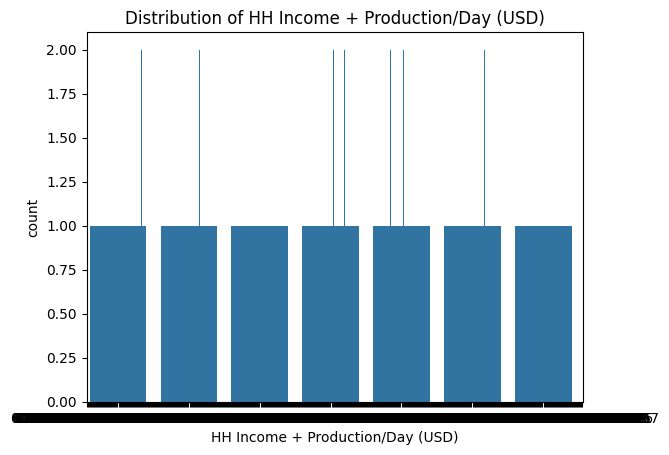

In [145]:
# Visualize the target variable distribution
sns.countplot(x=selected_data['HH Income + Production/Day (USD)'])
plt.title('Distribution of HH Income + Production/Day (USD)')
plt.show()

In [146]:
#Seperating target feature from other features
#Seperating the Target Feature (Column) from the Other Features Columns
X = selected_data.drop(['HH Income + Production/Day (USD)'], axis=1)
Y =  selected_data['HH Income + Production/Day (USD)']


In [147]:
##Spliting our dataset into training and Test data
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape,   y_test.shape)

(400, 4) (100, 4) (400,) (100,)


In [148]:
#Model Training
#RandomForestRegressor
#Loading the Model 
model = RandomForestRegressor(random_state=42)


In [149]:
#Training Our Model 
model.fit(x_train, y_train)
 


RandomForestRegressor(random_state=42)

In [150]:
#Model Predictions both on train and test data 
#Model predictions on training data
y_train_pred = model.predict(x_train)
#Model predictions on test data
y_test_pred = model.predict(x_test)

In [151]:
#Model Evaluations both on train data
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Mean Squared Error (MSE): {mse_train}")
print(f"Mean Absolute Error (MAE): {mae_train}")
print(f"R-squared (R2): {r2_train}")


Mean Squared Error (MSE): 0.5362035857244677
Mean Absolute Error (MAE): 0.5312988042839183
R-squared (R2): 0.7804934507560043


In [152]:
#Model Evaluations both on test data
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {mse_test}")
print(f"Mean Absolute Error (MAE): {mae_test}")
print(f"R-squared (R2): {r2_test}")


Mean Squared Error (MSE): 1.4758217949369934
Mean Absolute Error (MAE): 0.9145273105345162
R-squared (R2): 0.18335954080549333


In [125]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Perform grid search with cross-validation
model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)

best_model = grid_search.best_estimator_

In [153]:
#Model Predictions both on train and test data 
#Model predictions on training data
y_train_pred = best_model.predict(x_train)
#Model predictions on test data
y_test_pred = best_model.predict(x_test)

In [154]:
#Model Evaluations both on train data after parameter adjustments
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Mean Squared Error (MSE): {mse_train}")
print(f"Mean Absolute Error (MAE): {mae_train}")
print(f"R-squared (R2): {r2_train}")


Mean Squared Error (MSE): 1.6704701529862058
Mean Absolute Error (MAE): 0.9456004985610997
R-squared (R2): 0.316156869033859


In [155]:
#Model Evaluations both on test data
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {mse_test}")
print(f"Mean Absolute Error (MAE): {mae_test}")
print(f"R-squared (R2): {r2_test}")


Mean Squared Error (MSE): 1.3121902788028685
Mean Absolute Error (MAE): 0.8804622549603522
R-squared (R2): 0.27390442700577455
